# Preprocessing the complaints column

1. clean text
   - lowercase
   - remove punct/digits/special characeters
   - remove cfpb tokens XXXX
2. tokenize
3. stopwords removal
4. filter english words
5. lemmatize

In [22]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import words
import spacy
import string

In [23]:
data = pd.read_csv('data/product_complaints.csv')
data.head()

,product,complaints
0,credit_reporting,NaN
1,credit_card,NaN
2,credit_reporting,These are not my accounts.
3,credit_reporting,Kindly address this issue on my credit report....
4,credit_reporting,NaN


In [24]:
data.isnull().sum()

product              0
complaints    11407901
dtype: int64

In [25]:
data = data.dropna(subset=['complaints'])
print(data.isnull().sum())
print(data.head())

product       0
complaints    0
dtype: int64
            product                                         complaints
2  credit_reporting                         These are not my accounts.
3  credit_reporting  Kindly address this issue on my credit report....
5  credit_reporting  I wrote three requests, the unverified account...
6  credit_reporting  XXXX XXXX has a old account settled in XXXX th...
7             loans  They call at all hours and on the weekends usi...


In [26]:
data['product'].value_counts()

product
credit_reporting    2508471
debt_collection      422840
retail_banking       314368
credit_card          236957
loans                155345
mortgage             142617
Name: count, dtype: int64

In [27]:
data.info()

<class 'pandas.DataFrame'>
Index: 3780598 entries, 2 to 15188498
Data columns (total 2 columns):
 #   Column      Dtype
---  ------      -----
 0   product     str  
 1   complaints  str  
dtypes: str(2)
memory usage: 86.5 MB


- 3 million rows total is too large for this project.
- This takes too long for preprocessing, vectorization and topic modeling.
- So sampling around 60,000 data is the best choice.

## Sampling Dataset
- 10000 for each product categories for balance dataset

In [28]:
dfs = []
for cat in data['product'].unique():
    cat_df = data[data['product'] == cat]
    dfs.append(cat_df.sample(min(len(cat_df), 10000), random_state=42))

df_stratified = pd.concat(dfs).reset_index(drop=True)
print(df_stratified['product'].value_counts())

product
credit_reporting    10000
loans               10000
credit_card         10000
debt_collection     10000
retail_banking      10000
mortgage            10000
Name: count, dtype: int64


In [29]:
df_stratified.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   product     60000 non-null  str  
 1   complaints  60000 non-null  str  
dtypes: str(2)
memory usage: 937.6 KB


In [30]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])

# 1. Clean Text

In [31]:
def clean_text(text: str) -> str:
    text = text.lower() # lowercase
    text = re.sub(r'\bx+\b', ' ', text) # standalone 'x'
    text = re.sub(r'\bx+\d+\b', ' ', text) # x followed by digits
    text = re.sub(r'x{2,}', ' ', text) # x fused with other characters
    text = re.sub(r'[^a-z\s]', ' ', text) # replace non-letters
    text = re.sub(r'\s+', ' ', text).strip() # collapse multiple spaces
    return text    

In [32]:
sample = df_stratified.loc[100]["complaints"]
print(sample)
cleaned_sample = clean_text(sample)
print("----------------------------------")
print(cleaned_sample)

I XXXX XXXX contacted TransUnion on XX/XX/2021, I spoke to multiple employees as well as supervisors, regarding the fraudulent, inaccurate reporting on my credit report. Transunion knowingly and willingly broke the law regarding the written consent that I did not authorize. Nor did I give TransUnion the authority to furnish ANYTHING on my credit report, it is a direct violation of 15USC 1682 ( b ).

Pursuant to 15 U.S. Code 1681 ( n ) Transunion willfully failed to comply with the requirements imposed within the chapter and is civically liable for knowing noncompliance.
----------------------------------
i contacted transunion on i spoke to multiple employees as well as supervisors regarding the fraudulent inaccurate reporting on my credit report transunion knowingly and willingly broke the law regarding the written consent that i did not authorize nor did i give transunion the authority to furnish anything on my credit report it is a direct violation of usc b pursuant to u s code n tr

# 2. Remove Stopwords

In [33]:
# import ssl
# try:
#     _create_unverified_https_context = ssl._create_unverified_context
# except AttributeError:
#     pass
# else:
#     ssl._create_default_https_context = _create_unverified_https_context

In [34]:
# nltk.download('words')

In [35]:
#stopwords list
STOPWORDS = set(stopwords.words('english'))

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

english_words = set(words.words())

In [36]:
def tokenize(text: str) -> list:
    return word_tokenize(text)

def remove_stopwords(tokens: list) -> list:
    return [token for token in tokens if token not in STOPWORDS]

def remove_short_words(tokens: list, min_length: int = 3) -> list:
    return [token for token in tokens if len(token) >= min_length]

def filter_english(tokens: list) -> list:
    return [token for token in tokens if token in english_words]

# def lemmatize(tokens: list) -> list:
#     doc = nlp(' '.join(tokens))
#     return [token.lemma_ for token in doc if not token.is_stop and len(token.lemma_) >= 3 and token.lemma_.isalpha()]

In [37]:
from tqdm import tqdm

def preprocess_batch(texts: str) -> list:
    tokens_list = []
    cleaned = [clean_text(text) for text in texts]
    tokenized = [tokenize(text) for text in cleaned]
    no_stopwords = [remove_stopwords(tokens) for tokens in tokenized]
    no_short = [remove_short_words(tokens) for tokens in no_stopwords]
    filtered = [filter_english(tokens) for tokens in no_short]
    # lemmatization
    for doc in tqdm(nlp.pipe([' '.join(t) for t in filtered],
                             batch_size=500, disable=['parser', 'ner']), total=len(texts)):
        tokens = [
            token.lemma_
            for token in doc
            if len(token.lemma_) >= 3 and token.lemma_.isalpha()
        ]
        tokens_list.append(tokens)
    return tokens_list

In [38]:
sample = df_stratified.loc[100]["complaints"]
print(sample)
cleaned_sample = clean_text(sample)
tokenized_sample = preprocess_batch([cleaned_sample])
print("----------------------------------")
print(tokenized_sample)

I XXXX XXXX contacted TransUnion on XX/XX/2021, I spoke to multiple employees as well as supervisors, regarding the fraudulent, inaccurate reporting on my credit report. Transunion knowingly and willingly broke the law regarding the written consent that I did not authorize. Nor did I give TransUnion the authority to furnish ANYTHING on my credit report, it is a direct violation of 15USC 1682 ( b ).

Pursuant to 15 U.S. Code 1681 ( n ) Transunion willfully failed to comply with the requirements imposed within the chapter and is civically liable for knowing noncompliance.


100%|██████████| 1/1 [00:00<00:00, 31.51it/s]

----------------------------------
[['speak', 'multiple', 'well', 'regard', 'fraudulent', 'inaccurate', 'credit', 'report', 'knowingly', 'willingly', 'broke', 'law', 'regard', 'write', 'consent', 'authorize', 'give', 'authority', 'furnish', 'anything', 'credit', 'report', 'direct', 'violation', 'pursuant', 'code', 'willfully', 'comply', 'within', 'chapter', 'civically', 'liable', 'know', 'noncompliance']]


In [39]:
df_stratified['tokens'] = preprocess_batch(df_stratified['complaints'])

100%|██████████| 60000/60000 [05:41<00:00, 175.89it/s]


In [40]:
df_stratified.head()

,product,complaints,tokens
0,credit_reporting,I have reviewed my credit report and noticed i...,"[credit, report, incorrect, information, inacc..."
1,credit_reporting,"Seriously, it's been months since I investigat...","[seriously, since, credit, report, information..."
2,credit_reporting,SS # XXXX birthday XX/XX/year> This CFPB compl...,"[birthday, year, complaint, fill, request, pur..."
3,credit_reporting,"Upon reviewing my credit report, I have identi...","[upon, credit, report, inaccurate, need, corre..."
4,credit_reporting,They are a predatory lenders who are intention...,"[predatory, intentionally, erroneous, late, ha..."


In [41]:
df_stratified['tokens_str'] = df_stratified['tokens'].apply(lambda x: ' '.join(x))

In [42]:
df_stratified.head()

,product,complaints,tokens,tokens_str
0,credit_reporting,I have reviewed my credit report and noticed i...,"[credit, report, incorrect, information, inacc...",credit report incorrect information inaccurate...
1,credit_reporting,"Seriously, it's been months since I investigat...","[seriously, since, credit, report, information...",seriously since credit report information stil...
2,credit_reporting,SS # XXXX birthday XX/XX/year> This CFPB compl...,"[birthday, year, complaint, fill, request, pur...",birthday year complaint fill request pursuant ...
3,credit_reporting,"Upon reviewing my credit report, I have identi...","[upon, credit, report, inaccurate, need, corre...",upon credit report inaccurate need correction ...
4,credit_reporting,They are a predatory lenders who are intention...,"[predatory, intentionally, erroneous, late, ha...",predatory intentionally erroneous late hardshi...


In [43]:
df_stratified.to_pickle('data/preprocessed_data.pkl')

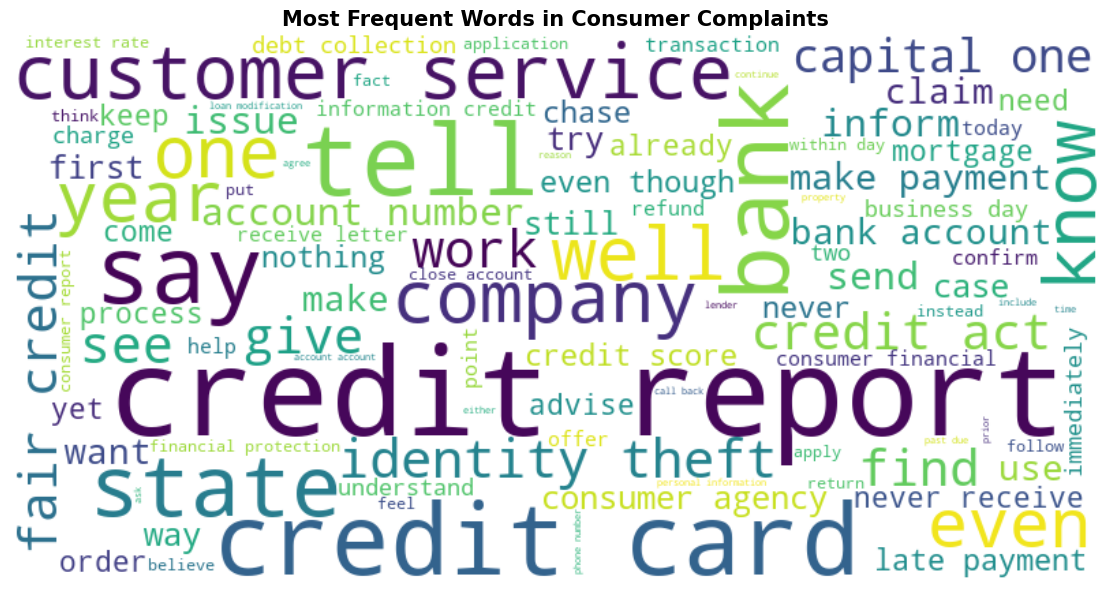

In [44]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join(df_stratified['tokens_str'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Consumer Complaints", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("export/overall_wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
